<a href="https://colab.research.google.com/github/zakyalkhair/alfagift-sentiment-analysis/blob/main/alfagift_bagofwords.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# **Alfagift Google App Review - Bag of Words**

In [5]:
from google.colab import files
import pandas as pd
uploaded = files.upload()
df_alfagiftrev = pd.read_csv(list(uploaded.keys())[0])
df_alfagiftrev['content'] = df_alfagiftrev['content'].astype(str)
df_alfagiftrev['content'] = df_alfagiftrev['content'].str.lower()
df_alfagiftrev.head()

Saving df_alfagiftrev_preprocessing (3).csv to df_alfagiftrev_preprocessing (3) (1).csv


,content,score,sentiment_polarity,review_length,sentiment_subjective,sentiment_rating,at,content_cleaned,wordCount,wordCount_after_stopwords
0,parah sesi anda telah selesai ngapain coba kel...,1,0.0,77,0.0,Negative,2026-03-30 13:39:27,parah sesi selesai ngapain coba keluara gunaka,13,7
1,tolong pihak alfamart sediakan jual rokok,2,0.0,46,0.0,Negative,2026-03-30 13:33:37,tolong alfamart sediakan jual rokok,6,5
2,ini gaada menu cancel orderan kah,3,0.0,36,0.0,Neutral,2026-03-30 13:11:09,gaada menu cancel orderan kah,6,5
3,percuma ada chat aplikasi kalo gapernah dibaca...,1,0.0,195,0.0,Negative,2026-03-30 12:57:09,chat aplikasi gapernah dibaca mending klik idm...,35,24
4,udah nyaman eh alfamart nya pindah jadi jauh s...,2,0.0,89,0.0,Negative,2026-03-30 12:46:39,udah nyaman eh alfamart pindah 1 jam pembayara...,16,11


In [6]:
from collections import Counter
import re

# gabungkan semua teks
all_text = ' '.join(df_alfagiftrev['content_cleaned'].astype(str))

# tokenisasi sederhana
tokens = re.findall(r'\b\w+\b', all_text.lower())

# hitung frekuensi
bow_manual = Counter(tokens)

# tampilkan 20 kata paling sering
bow_manual.most_common(20)

[('belanja', 34666),
 ('aplikasi', 30949),
 ('alfagift', 28003),
 ('membantu', 17653),
 ('promo', 17078),
 ('bagus', 14348),
 ('cepat', 14324),
 ('banget', 13709),
 ('mudah', 13423),
 ('pengiriman', 12917),
 ('alfamart', 11874),
 ('mantap', 10026),
 ('kirim', 9505),
 ('barang', 9374),
 ('rumah', 9149),
 ('ongkos', 7779),
 ('gratis', 7477),
 ('berbelanja', 6796),
 ('ya', 6623),
 ('alfa', 6185)]

In [9]:
from sklearn.feature_extraction.text import CountVectorizer

# inisialisasi vectorizer
vectorizer = CountVectorizer(
    max_features=1000,     # ambil 1000 kata paling penting
    ngram_range=(1,2),     # unigram + bigram
    min_df=5,              # minimal muncul di 5 dokumen
    max_df=0.8             # buang kata terlalu umum
)

# fit dan transform
X = vectorizer.fit_transform(df_alfagiftrev['content_cleaned'].astype(str))

# ubah ke dataframe
bow_df = pd.DataFrame(
    X.toarray(),
    columns=vectorizer.get_feature_names_out()
)

bow_df.head()

,10,100,11,12,15,2x,30,30 menit,abis,ad,...,voucer,voucher,voucher belanja,vouchernya,wa,wifi,wow,ya,ya alfagift,yaa
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [13]:
import numpy as np

word_counts = np.sum(X.toarray(), axis=0)
words = vectorizer.get_feature_names_out()

word_freq = pd.DataFrame({
    'word': words,
    'frequency': word_counts
}).sort_values(by='frequency', ascending=False)

word_freq.head(20)

,word,frequency
137,belanja,34666
68,aplikasi,30949
24,alfagift,28003
564,membantu,17653
776,promo,17078
91,bagus,14348
227,cepat,14324
102,banget,13709
619,mudah,13423
727,pengiriman,12917


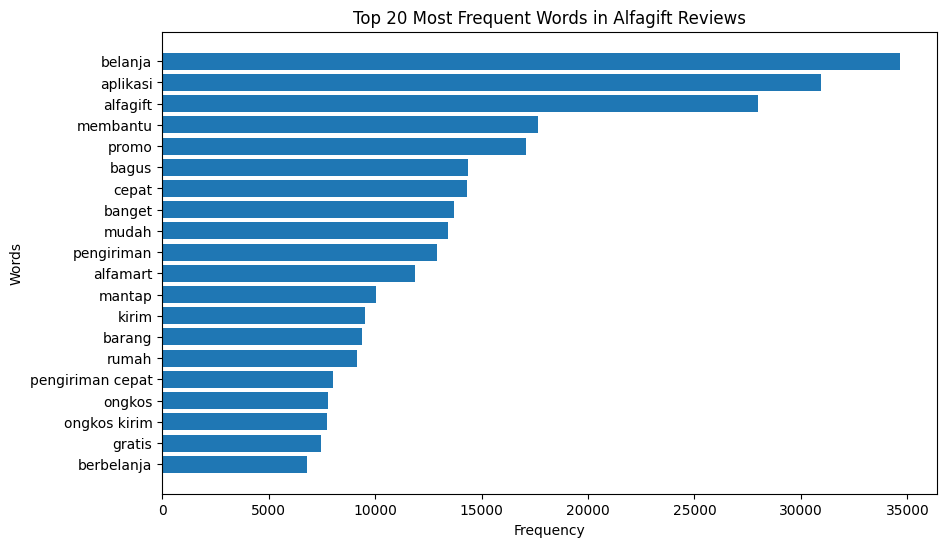

In [14]:
import matplotlib.pyplot as plt

top_n = 20
top_words = word_freq.head(top_n)

plt.figure(figsize=(10,6))
plt.barh(top_words['word'], top_words['frequency'])
plt.gca().invert_yaxis()
plt.title('Top 20 Most Frequent Words in Alfagift Reviews')
plt.xlabel('Frequency')
plt.ylabel('Words')
plt.show()

In [24]:
vectorizer_bigram = CountVectorizer(
    ngram_range=(2,2),
    min_df=5,
    max_features=20
)

# Ensure no NaN values are present in the 'content_cleaned' column
X_bigram = vectorizer_bigram.fit_transform(df_alfagiftrev['content_cleaned'].fillna(''))

bigram_counts = np.sum(X_bigram.toarray(), axis=0)

bigram_df = pd.DataFrame({
    'bigram': vectorizer_bigram.get_feature_names_out(),
    'frequency': bigram_counts
}).sort_values(by='frequency', ascending=False)

bigram_df

,bigram,frequency
16,pengiriman cepat,8013
15,ongkos kirim,7754
12,gratis ongkos,5678
9,belanja mudah,3553
3,aplikasi membantu,3509
7,belanja alfagift,3062
1,aplikasi alfagift,3057
10,belanja online,2433
2,aplikasi bagus,2381
0,alfa gift,2264


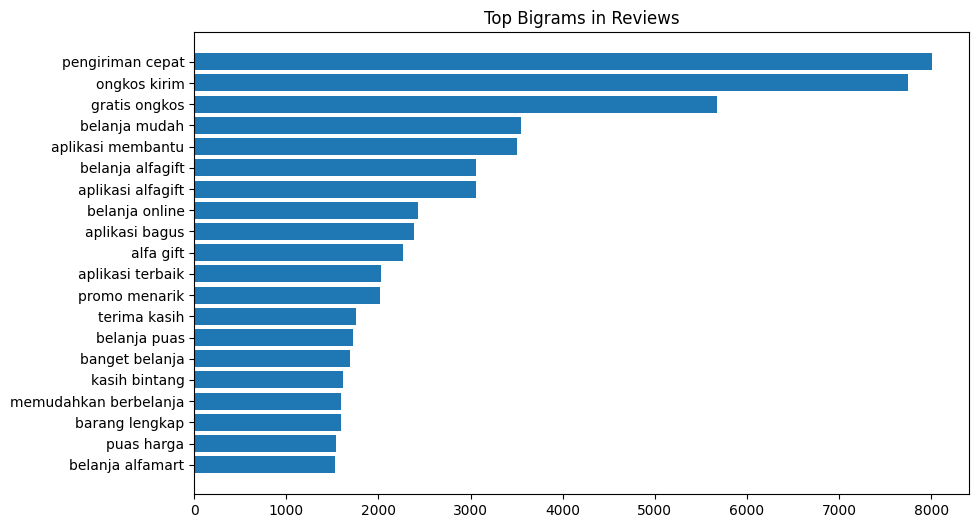

In [25]:
plt.figure(figsize=(10,6))
plt.barh(bigram_df['bigram'], bigram_df['frequency'])
plt.gca().invert_yaxis()
plt.title('Top Bigrams in Reviews')
plt.show()